In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype(np.float32) / 255.0
x_train = np.expand_dims(x_train, -1)

print(x_train.shape)

(60000, 28, 28, 1)


In [2]:
class ForwardDiffusion:

    def __init__(self, steps=200):

        self.steps = steps

    def linear_schedule(self):

        beta = np.linspace(
            1e-4,
            0.02,
            self.steps
        )

        alpha = 1 - beta

        alpha_bar = np.cumprod(alpha)

        return beta, alpha, alpha_bar

    def cosine_schedule(self, s=0.008):

        t = np.linspace(0, self.steps, self.steps + 1)

        f = np.cos(
            ((t / self.steps) + s) / (1 + s) * np.pi / 2
        ) ** 2

        alpha_bar = f / f[0]

        beta = []

        for i in range(self.steps):
            beta.append(
                min(
                    1 - alpha_bar[i + 1] / alpha_bar[i],
                    0.999
                )
            )

        beta = np.array(beta)

        alpha = 1 - beta

        alpha_bar = np.cumprod(alpha)

        return beta, alpha, alpha_bar

    def offset_cosine_schedule(self, offset=0.1):

        t = np.linspace(0, self.steps, self.steps + 1)

        f = np.cos(
            ((t / self.steps) + offset) /
            (1 + offset) * np.pi / 2
        ) ** 2

        alpha_bar = f / f[0]

        beta = []

        for i in range(self.steps):
            beta.append(
                min(
                    1 - alpha_bar[i + 1] / alpha_bar[i],
                    0.999
                )
            )

        beta = np.array(beta)

        alpha = 1 - beta

        alpha_bar = np.cumprod(alpha)

        return beta, alpha, alpha_bar

    def add_noise(self, image, t, alpha_bar):

        noise = tf.random.normal(image.shape)

        noisy = (
            np.sqrt(alpha_bar[t]) * image +
            np.sqrt(1 - alpha_bar[t]) * noise
        )

        return noisy

In [3]:
diffusion = ForwardDiffusion(steps=200)

In [4]:
_, _, alpha_bar_linear = diffusion.linear_schedule()
_, _, alpha_bar_cosine = diffusion.cosine_schedule()
_, _, alpha_bar_offset = diffusion.offset_cosine_schedule()

In [5]:
def show_forward_process(image, alpha_bar, title):

    steps = [0, 50, 100, 150, 199]

    plt.figure(figsize=(15,3))

    for i, t in enumerate(steps):

        noisy = diffusion.add_noise(image, t, alpha_bar)

        plt.subplot(1,5,i+1)

        plt.imshow(noisy.numpy().squeeze(), cmap='gray')

        plt.title(f"t={t+1}")

        plt.axis("off")

    plt.suptitle(title)

    plt.show()

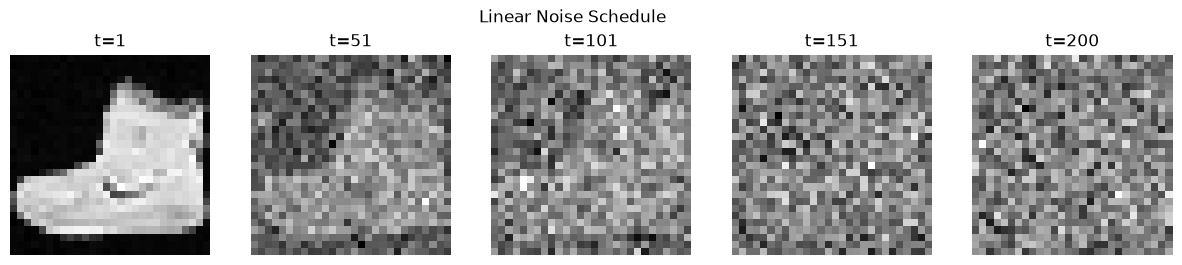

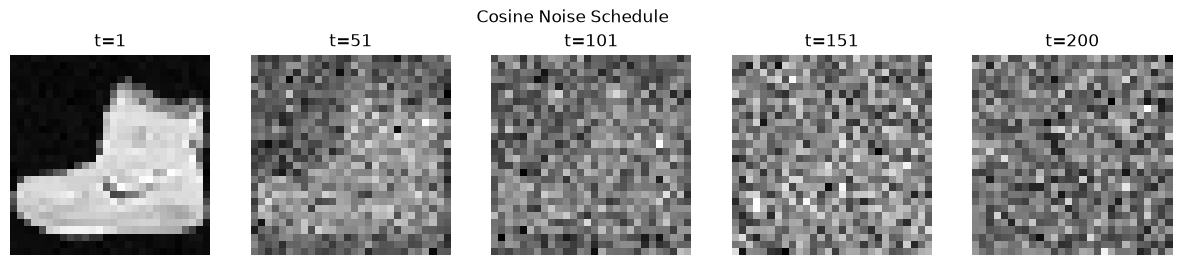

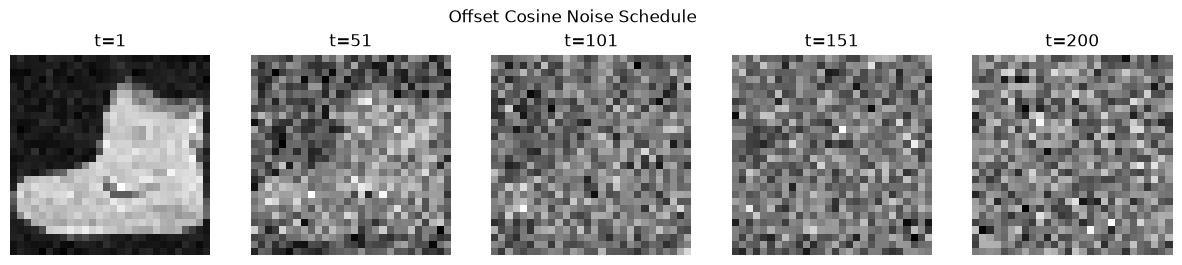

In [6]:
image = x_train[0]
show_forward_process(
    image,
    alpha_bar_linear,
    "Linear Noise Schedule"
)
show_forward_process(
    image,
    alpha_bar_cosine,
    "Cosine Noise Schedule"
)
show_forward_process(
    image,
    alpha_bar_offset,
    "Offset Cosine Noise Schedule"
)